# Train Model Workflow

This notebook mirrors `train_model.py`, organized into logical steps.

## 1. Imports

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMClassifier, LGBMRegressor
import joblib

## 2. Load And Prepare Dataset

In [64]:
# Load dataset
df = pd.read_csv('dataset.csv')
df = df.sort_values(by='game_date')  # Sort by date

In [65]:
df.drop(columns=['fast_break_pct_avg_diff','fast_break_pct_rolling_5_diff','points_off_turnover_pct_avg_diff','points_off_turnover_pct_rolling_5_diff'], inplace=True)

In [66]:
print("Number of nulls per column in df (ordered by highest nulls first):")
null_counts = df.isnull().sum().sort_values(ascending=False)
for col, count in null_counts.items():
    print(f"{col}: {count}")

Number of nulls per column in df (ordered by highest nulls first):
game_id: 0
season: 0
season_type: 0
game_date: 0
team_home_away: 0
team_winner: 0
is_early_season: 0
sos: 0
sos_opp: 0
adj_sos: 0
adj_sos_opp: 0
off_vs_def: 0
def_vs_off: 0
tov_vs_stl: 0
stl_vs_tov: 0
orb_vs_drb: 0
drb_vs_orb: 0
pace_diff: 0
exp_poss: 0
efg_vs_efg_allowed: 0
efg_allowed_vs_efg: 0
margin_estimate: 0
home_off_away_def: 0
home_def_away_off: 0
away_off_home_def: 0
away_def_home_off: 0
three_pct_diff: 0
three_pct_opponent_diff: 0
three_attempt_rate_diff: 0
allowed_three_attempt_rate_diff: 0
three_variance_diff: 0
score_variance_diff: 0
def_score_variance_diff: 0
off_eff_variance_diff: 0
pace_variance_diff: 0
last_10_efficiency_diff: 0
team_score_avg_diff: 0
team_score_rolling_5_diff: 0
opponent_team_score_avg_diff: 0
opponent_team_score_rolling_5_diff: 0
poss_avg_diff: 0
poss_rolling_5_diff: 0
poss_opponent_avg_diff: 0
poss_opponent_rolling_5_diff: 0
off_eff_avg_diff: 0
off_eff_rolling_5_diff: 0
def_eff_avg_

## 3. Train/Test Split And Shared Config

In [67]:
# Split train/test based on date
split_date = '2024-11-01'
df['target'] = df['team_winner']
df.drop(columns=['team_winner'], inplace=True)
train_df = df[df['game_date'] <= split_date].copy()
test_df = df[df['game_date'] > split_date].copy()
train_df.drop(columns=['game_date','game_id'], inplace=True)
test_df.drop(columns=['game_date','game_id'], inplace=True)

In [68]:
train_df.tail(10)

,season,season_type,team_home_away,is_early_season,sos,sos_opp,adj_sos,adj_sos_opp,off_vs_def,def_vs_off,...,conference_strength_diff,win_loss_pct_diff,non_conf_win_loss_pct_diff,conference_nonconf_win_pct_diff,luck_diff,adj_off_eff_diff,adj_def_eff_diff,adj_net_eff_diff,power_rating_diff,target
202854,2024,3,2,1,3.688678,8.262027,17.183823,25.126005,23.085653,9.218910,...,-9.838016,0.217460,-0.043288,-0.089838,0.098882,14.987863,11.630836,3.357027,-4.585154,1
202855,2024,3,2,1,8.262027,3.688678,25.126005,17.183823,9.218910,23.085653,...,9.838016,-0.217460,0.043288,0.089838,-0.098882,-14.987863,-11.630836,-3.357027,4.585154,0
202858,2024,3,2,1,3.910283,8.100874,17.555807,19.470249,17.586461,10.741933,...,-5.423743,0.166667,-0.016115,-0.026650,-0.021288,6.714141,5.393818,1.320322,-0.594120,0
202859,2024,3,2,1,8.100874,3.910283,19.470249,17.555807,10.741933,17.586461,...,5.423743,-0.166667,0.016115,0.026650,0.021288,-6.714141,-5.393818,-1.320322,0.594120,1
202860,2024,3,2,1,7.451850,8.056203,11.000891,42.733829,10.869576,19.073751,...,-3.413597,-0.250866,-0.031451,-0.031961,0.015924,-7.467502,-5.912677,-1.554825,-33.287763,0
202861,2024,3,2,1,8.056203,7.451850,42.733829,11.000891,19.073751,10.869576,...,3.413597,0.250866,0.031451,0.031961,-0.015924,7.467502,5.912677,1.554825,33.287763,1
202862,2024,3,2,1,13.177322,5.806761,34.462394,39.195581,31.347919,15.315851,...,4.011026,-0.226608,0.041670,0.050914,-0.079688,19.618013,13.700376,5.917638,1.184451,0
202863,2024,3,2,1,5.806761,13.177322,39.195581,34.462394,15.315851,31.347919,...,-4.011026,0.226608,-0.041670,-0.050914,0.079688,-19.618013,-13.700376,-5.917638,-1.184451,1
202864,2024,3,2,1,7.896952,6.117722,42.350355,39.434453,29.066723,27.539763,...,2.722381,-0.028340,-0.002698,0.019550,0.011819,2.016305,1.293850,0.722455,3.638356,0
202865,2024,3,2,1,6.117722,7.896952,39.434453,42.350355,27.539763,29.066723,...,-2.722381,0.028340,0.002698,-0.019550,-0.011819,-2.016305,-1.293850,-0.722455,-3.638356,1


## 4. Train Winner Prediction Model

In [69]:
# Winner prediction model (classification)

# Drop the other target column to avoid leakage
X_train_winner = train_df.drop(columns=['target'])
y_train_winner = train_df['target'].astype(int)

X_test_winner = test_df.drop(columns=['target'])
y_test_winner = test_df['target'].astype(int)

print(X_train_winner.columns.to_list())

# Improved model parameters for better generalization and handling nonlinearity
winner_params = dict(
    objective="binary",
    metric="binary_logloss",
    boosting_type="gbdt",
    learning_rate=0.012,           # Slower learning rate for more robust learning
    n_estimators=6000,             # More trees to compensate for lower learning rate
    max_depth=8,                   # Slightly deeper trees to fit more complex patterns
    num_leaves=128,                # More leaves to capture nonlinearity
    min_child_samples=50,          # Reduce overfitting, but not too high to retain learning small data regions
    feature_fraction=0.85,         # Try more features per tree
    bagging_fraction=0.85,         # Slightly more bagging for generalization
    bagging_freq=1,
    lambda_l1=1.0,                 # Slightly stronger L1 to encourage sparsity
    lambda_l2=10.0,                # Slightly stronger L2 for regularization
    min_gain_to_split=0.015,       # Require a bit more information gain to split
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

model_winner = LGBMClassifier(**winner_params)

print("\nTraining winner prediction model (improved hyperparameters)...")
model_winner.fit(X_train_winner, y_train_winner)

['season', 'season_type', 'team_home_away', 'is_early_season', 'sos', 'sos_opp', 'adj_sos', 'adj_sos_opp', 'off_vs_def', 'def_vs_off', 'tov_vs_stl', 'stl_vs_tov', 'orb_vs_drb', 'drb_vs_orb', 'pace_diff', 'exp_poss', 'efg_vs_efg_allowed', 'efg_allowed_vs_efg', 'margin_estimate', 'home_off_away_def', 'home_def_away_off', 'away_off_home_def', 'away_def_home_off', 'three_pct_diff', 'three_pct_opponent_diff', 'three_attempt_rate_diff', 'allowed_three_attempt_rate_diff', 'three_variance_diff', 'score_variance_diff', 'def_score_variance_diff', 'off_eff_variance_diff', 'pace_variance_diff', 'last_10_efficiency_diff', 'team_score_avg_diff', 'team_score_rolling_5_diff', 'opponent_team_score_avg_diff', 'opponent_team_score_rolling_5_diff', 'poss_avg_diff', 'poss_rolling_5_diff', 'poss_opponent_avg_diff', 'poss_opponent_rolling_5_diff', 'off_eff_avg_diff', 'off_eff_rolling_5_diff', 'def_eff_avg_diff', 'def_eff_rolling_5_diff', 'net_eff_avg_diff', 'net_eff_rolling_5_diff', 'efg_avg_diff', 'efg_roll

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,8
,learning_rate,0.012
,n_estimators,6000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


## 5. Removed

## 6. Save Models

In [74]:
joblib.dump(model_winner, 'models/lgbm_winner_model.joblib')

['models/lgbm_winner_model.joblib']

## 7. Define Evaluation Helper

In [70]:
def evaluate_classification_thresholds(model, X_test, y_test, model_name):
    from sklearn.metrics import matthews_corrcoef

    thresholds = np.linspace(0.1, 0.8, 10)  # Test thresholds from 0.1 to 0.8
    metrics = []

    # Get probabilities once
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Create mask for actual 0 values (away team wins)
    actual_zero_mask = (y_test == 0)

    for thresh in thresholds:
        # Get predictions based on threshold
        y_pred_thresh = (y_pred_proba > thresh).astype(int)

        # Calculate standard metrics
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)
        accuracy = accuracy_score(y_test, y_pred_thresh)
        mcc = matthews_corrcoef(y_test, y_pred_thresh)

        # Calculate accuracy for cases where the actual value is 0
        # This shows how well the model identifies games where away team wins
        if np.sum(actual_zero_mask) > 0:
            actual_zero_accuracy = accuracy_score(
                y_test[actual_zero_mask],
                y_pred_thresh[actual_zero_mask]
            )
        else:
            actual_zero_accuracy = 0

        metrics.append([thresh, precision, recall, f1, accuracy, actual_zero_accuracy, mcc])

    # Convert to DataFrame
    metrics_df = pd.DataFrame(
        metrics,
        columns=[
            "Threshold", "Precision", "Recall", "F1 Score", "Accuracy", "Accuracy_Actual_0", "Matthews_CC"
        ]
    )

    # Plot metrics
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=metrics_df, x="Threshold", y="Precision", label="Precision", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Recall", label="Recall", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="F1 Score", label="F1 Score", marker="o")
    sns.lineplot(data=metrics_df, x="Threshold", y="Accuracy", label="Accuracy", marker="o")
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Accuracy_Actual_0",
        label="Accuracy When Away Team Wins",
        marker="o",
        linestyle="--",
        color="purple"
    )
    sns.lineplot(
        data=metrics_df,
        x="Threshold",
        y="Matthews_CC",
        label="Matthews Corr. Coefficient",
        marker="o",
        linestyle="--",
        color="darkgreen"
    )

    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Optimization - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print count of actual away team wins
    print(f"Number of actual away team wins in test set: {np.sum(actual_zero_mask)}")
    print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    # Find and return the best threshold based on Matthews Correlation Coefficient (MCC)
    best_threshold = metrics_df.loc[metrics_df["Matthews_CC"].idxmax(), "Threshold"]
    return best_threshold


## 8. Evaluate Models

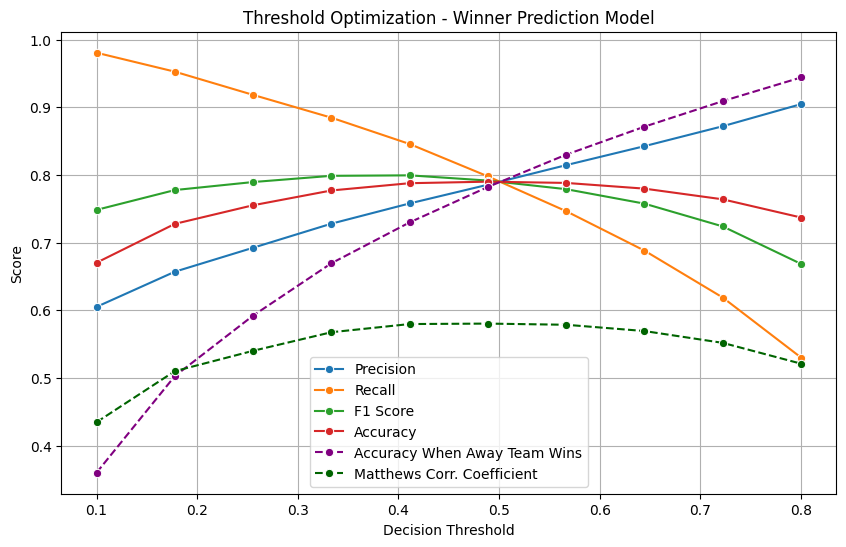

Number of actual away team wins in test set: 11075
ROC AUC: 0.8790

Optimal Decision Threshold (Winner Model): 0.49


In [71]:
best_thresh_winner = evaluate_classification_thresholds(model_winner, X_test_winner, y_test_winner, "Winner Prediction Model")

print(f"\nOptimal Decision Threshold (Winner Model): {best_thresh_winner:.2f}")

## 9. Define Feature Importance Helper

In [72]:
def plot_feature_importance(model, X_train, model_name):
    feature_importances = model.feature_importances_
    feature_names = X_train.columns

    feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    top_20_features = feat_importance_df.sort_values(by="Importance", ascending=False).head(30)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature Name")
    plt.title(f"Top 20 Features - {model_name}")
    plt.show()

## 10. Plot Feature Importances

C:\Users\johns\AppData\Local\Temp\ipykernel_28200\3882313398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_20_features, palette="viridis")


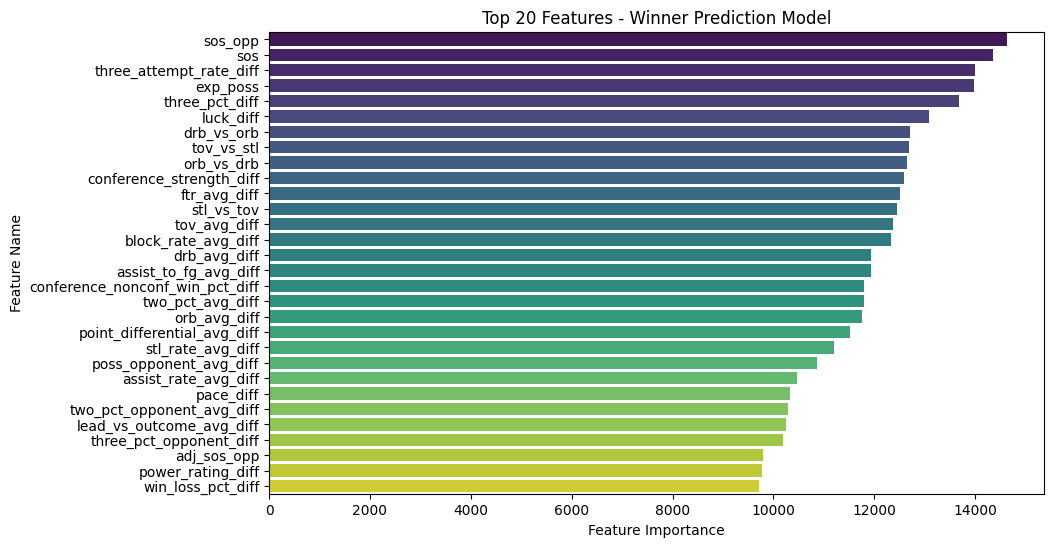

In [73]:
plot_feature_importance(model_winner, X_train_winner, "Winner Prediction Model")